In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import offsetbox
from sklearn import (manifold, datasets, preprocessing)
from sklearn.preprocessing import StandardScaler
import time

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
# Load the digits dataset
digits = datasets.load_digits(n_class=10)
X = digits.data
y = digits.target
n_samples, n_features = X.shape

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {n_samples}, Number of features: {n_features}")

# Scale the data
# This is important for many ML algorithms
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dataset shape: (1797, 64)
Number of samples: 1797, Number of features: 64


In [8]:
# Load the digits dataset
digits = datasets.load_digits(n_class=10)
X = digits.data
y = digits.target
n_samples, n_features = X.shape

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {n_samples}, Number of features: {n_features}")

# Scale the data
# This is important for many ML algorithms
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dataset shape: (1797, 64)
Number of samples: 1797, Number of features: 64


In [10]:
# This function plots the 2D results
def plot_embedding(X_2D, y, title=None):
    """
    Plots a 2D embedding with points colored by their class label.
    """
    # Create a scatter plot
    plt.figure(figsize=(10, 8))
    
    # Get all unique labels
    labels = np.unique(y)
    
    # Use a discrete colormap
    cmap = plt.cm.get_cmap("jet", len(labels))
    
    for i, label in enumerate(labels):
        # Find all points belonging to this class
        indices = (y == label)
        # Plot them
        plt.scatter(X_2D[indices, 0], X_2D[indices, 1], 
                    c=[cmap(i)], label=str(label), s=15)
        
    plt.xticks([])
    plt.yticks([])
    plt.legend(loc='best', markerscale=2., title="Digit")
    if title:
        plt.title(title, fontsize=16)
    
    plt.show()

print("Plotting function defined.")

Plotting function defined.


In [11]:
# This function plots the 2D results
def plot_embedding(X_2D, y, title=None):
    """
    Plots a 2D embedding with points colored by their class label.
    """
    # Create a scatter plot
    plt.figure(figsize=(10, 8))
    
    # Get all unique labels
    labels = np.unique(y)
    
    # Use a discrete colormap
    cmap = plt.cm.get_cmap("jet", len(labels))
    
    for i, label in enumerate(labels):
        # Find all points belonging to this class
        indices = (y == label)
        # Plot them
        plt.scatter(X_2D[indices, 0], X_2D[indices, 1], 
                    c=[cmap(i)], label=str(label), s=15)
        
    plt.xticks([])
    plt.yticks([])
    plt.legend(loc='best', markerscale=2., title="Digit")
    if title:
        plt.title(title, fontsize=16)
    
    plt.show()

print("Plotting function defined.")

Plotting function defined.


Starting t-SNE... (This may take a moment)
t-SNE completed in 3.17 seconds.


C:\Users\jesli\AppData\Local\Temp\ipykernel_31928\3010647069.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("jet", len(labels))


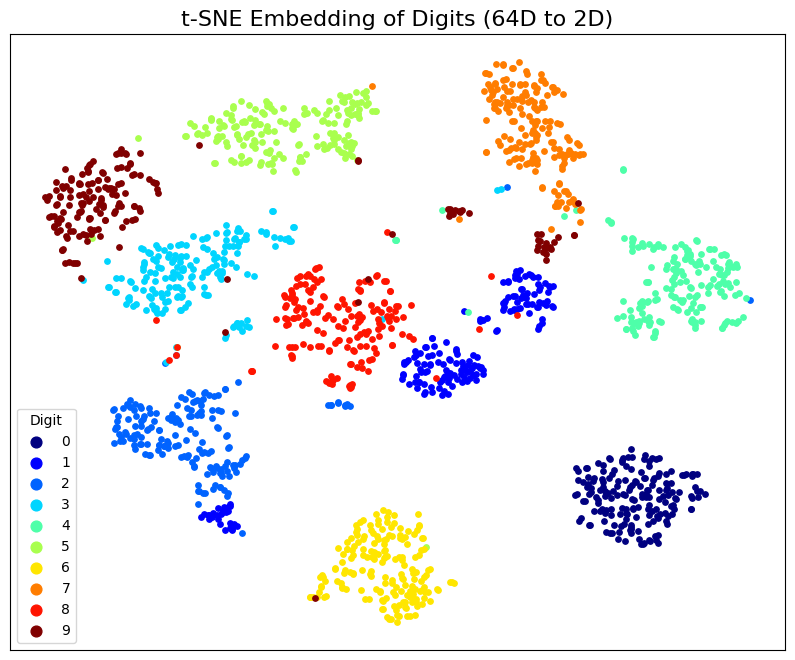

In [12]:
print("Starting t-SNE... (This may take a moment)")
start_time = time.time()

# Initialize t-SNE
tsne = manifold.TSNE(n_components=2, 
                       perplexity=30, 
                       init='pca', 
                       n_iter=1000,
                       random_state=42)

# Fit and transform the scaled data
X_tsne = tsne.fit_transform(X_scaled)

end_time = time.time()
print(f"t-SNE completed in {end_time - start_time:.2f} seconds.")

# Plot the t-SNE results
plot_embedding(X_tsne, y, "t-SNE Embedding of Digits (64D to 2D)")

Starting LLE... (This may also take a moment)
LLE completed in 1.71 seconds.


C:\Users\jesli\AppData\Local\Temp\ipykernel_31928\3010647069.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("jet", len(labels))


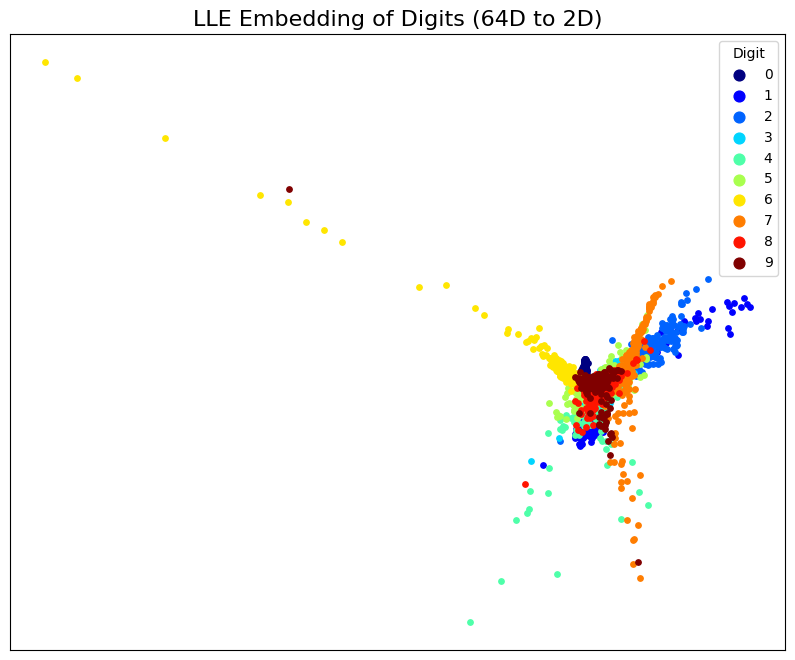

In [13]:
print("Starting LLE... (This may also take a moment)")
start_time = time.time()

# Initialize LLE
# n_neighbors must be > n_components
lle = manifold.LocallyLinearEmbedding(n_components=2, 
                                        n_neighbors=20, 
                                        method='standard',
                                        random_state=42)

# Fit and transform the scaled data
X_lle = lle.fit_transform(X_scaled)

end_time = time.time()
print(f"LLE completed in {end_time - start_time:.2f} seconds.")

# Plot the LLE results
plot_embedding(X_lle, y, "LLE Embedding of Digits (64D to 2D)")